# Minimum fire-size filter on the overlap maps

**Purpose.** Both models drop predicted burn patches smaller than a minimum size
(25 pixels by default) as a clean-up step. We test whether raising that minimum,
from 25 up to 200 pixels, still helps *after* the overlap vote has already removed
some false alarms. We study the 50% overlap run at two voting strictnesses, a
plain majority (50 percent of windows) and a strict vote (75 percent).

**Dataset.** The 50% overlap burned-area maps of tile T29TPG for both Swin-YNet
and EfficientNet-B2 (before 2025-07-07, after 2025-10-15), thresholded at vote 50
and 75 percent, scored against the ICNF fire records filtered to the window and
clipped to Portugal.

**Objectives.** (1) Tabulate the scores for every vote and minimum-size pair;
(2) see how the minimum size changes F1 and MCC; (3) show the precision-recall
trade; (4) track the burned area; (5) map where the filter cleans up.

**Method.** We do not re-run the models. We take the 50% overlap vote map, turn it
into a burned map at each vote threshold, find the connected burned patches on the
full tile, and remove patches below each size threshold (25, 50, ..., 200 pixels;
one pixel is 100 square metres).

**Observation.** Per-fire recall declined monotonically with increasing min_size_px for fires below 20 ha, most sharply in the [1–10[ ha class (0.796 raw → 0.341 at 500 px) and [10–20[ ha class (0.912 → 0.700), with the rate of loss accelerating beyond ~150–200 px. Recall for fires ≥20 ha was invariant across the entire 0–500 px range, while the ]0–1[ ha class showed comparatively low recall even without filtering (0.385).

**Interpretation.** The size filter suppresses true detections in the 1–20 ha range rather than false positives, and this loss is masked in area-weighted aggregate metrics because that stratum contributes negligible total burned area. A threshold of 100 px (1 ha) is the better-justified setting: it aligns with ICNF's own ]0–1[/[1–10[ class boundary, preserves most of the genuine signal in the 1–20 ha classes (within ~3–6pp of raw recall), and confines its cost mainly to the ]0–1[ class, which is already near the model's detection limit regardless of filtering.

**Conclusion:** min_size_px ≈ 100 (1 ha)

## 1. Setup and data

This section loads the overlap vote maps and the ground truth, builds the burned
maps at vote 50 and 75 percent, and labels the burned patches once each so the
size sweep is cheap.

### 1.1 Environment and plotting style

Import the libraries and set one clean style, a colour per model, and a line style
per vote threshold.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.ndimage import label as ndlabel

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 140, "font.size": 11,
    "axes.titlesize": 12, "axes.titleweight": "medium",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
MODEL_COLOR = {"swin_ynet": "#4477aa", "efficientnet_b2": "#cc6677"}
MODEL_LABEL = {"swin_ynet": "Swin-YNet", "efficientnet_b2": "EfficientNet-B2"}
VOTE_LS = {50: "-", 75: "--"}                 # line style per vote threshold
C_AGREE = "#762a83"; C_FALSE = "#d6604d"; C_MISS = "#2c7bb6"

for _c in (Path.cwd(), Path.cwd().parent):
    if (_c / "utils" / "config.py").exists():
        sys.path.insert(0, str(_c)); break
from utils.config import load_config
cfg = load_config()

### 1.2 Load the vote maps and label the burned patches

We use the 50% overlap run. The vote map gives, for each pixel, the percent of
covering windows that voted burned. Turning it into a burned map at vote 50 and 75
percent gives four base maps (two models times two thresholds). We label the
connected burned patches on each one time; every patch keeps its size in pixels.

In [2]:
BEFORE, AFTER = "2025-07-07", "2025-10-15"
B, A = BEFORE.replace("-", ""), AFTER.replace("-", "")
PRED   = cfg.predictions_dir
LABELS = cfg.repo_root / "data/processed/icnf_burned_labels_t29tpg_2025.tif"
ICNF_SHP = cfg.repo_root / "data/shapefiles/ground_truth_ICNF/ardida_2025.shp"
PT_BOUND = cfg.repo_root / "data/shapefiles/boundary_files/portugal_continental_32629.gpkg"
PIX_HA = 0.01
MODELS = ["efficientnet_b2", "swin_ynet"]
OVERLAP = 50                 # study the 50% overlap run
VOTE_PCTS = [50, 75]         # 2 of 4 and 3 of 4 covering windows

def read(p):
    with rasterio.open(p) as r: return r.read(1)

def votes_path(mdl):    return PRED / f"T29TPG_{mdl}_ov{OVERLAP:02d}_{B}_{A}_votes.tif"
def observed_path(mdl): return PRED / f"T29TPG_{mdl}_ov{OVERLAP:02d}_{B}_{A}_observed.tif"

labels_img = read(LABELS)
with rasterio.open(LABELS) as _r:
    GRID_T, GRID_SHAPE = _r.transform, (_r.height, _r.width)
    EXTENT = (_r.bounds.left, _r.bounds.right, _r.bounds.bottom, _r.bounds.top)
PT = gpd.read_file(PT_BOUND).to_crs("EPSG:32629")
inside_pt = rasterize([(g, 1) for g in PT.geometry], out_shape=GRID_SHAPE,
                      transform=GRID_T, fill=0, dtype="uint8").astype(bool)
scored = (labels_img != 255) & inside_pt
comp = (read(observed_path(MODELS[0])) == 1) & scored

# Build burned maps at each vote threshold and label them once.
patches = {}
for mdl in MODELS:
    v = read(votes_path(mdl))                       # percent of windows voting burned
    for vp in VOTE_PCTS:
        burned = (v != 255) & (v >= vp)
        lab, n = ndlabel(burned)
        sizes = np.bincount(lab.ravel())            # sizes[0] is the background
        patches[(mdl, vp)] = (lab, sizes)
        print(f"{MODEL_LABEL[mdl]}, {vp}% vote: {n:,} burned patches")

EfficientNet-B2, 50% vote: 7,854 burned patches
EfficientNet-B2, 75% vote: 5,684 burned patches
Swin-YNet, 50% vote: 3,000 burned patches
Swin-YNet, 75% vote: 2,177 burned patches


### 1.3 Ground truth within the window

Keep only ICNF fires that started on or after the before image and ended on or
before the after image, shrink each by one pixel, and rasterize.

One side effect to keep in mind: fires that fall partly outside this date window
are dropped from the truth but can still be detected, so they count as false
positives and slightly lower the measured precision. In this tile that is about
916 ha, small next to the area each setting flags.

In [3]:
fires = gpd.read_file(ICNF_SHP).to_crs("EPSG:32629")
fires = fires.cx[EXTENT[0]:EXTENT[1], EXTENT[2]:EXTENT[3]].copy()
fires["s"] = pd.to_datetime(fires["DH_Inicio"]); fires["e"] = pd.to_datetime(fires["DH_Fim"])
sel = fires[(fires["s"] >= pd.Timestamp(BEFORE)) & (fires["e"] <= pd.Timestamp(AFTER))]
geoms = [g for g in sel.geometry.buffer(-10) if not g.is_empty]
truth = rasterize([(g, 1) for g in geoms], out_shape=GRID_SHAPE,
                  transform=GRID_T, fill=0, dtype="uint8").astype(bool)
t = truth & comp
print(f"ground-truth fire in window: {t.sum()*PIX_HA:,.0f} ha")

ground-truth fire in window: 10,636 ha


## 2. Effect of the minimum fire size

This section measures how raising the minimum patch size changes the result, for
each vote threshold. It matters because the vote has already removed some false
alarms, so this shows whether the size filter still adds anything on top.

### 2.1 Scores versus the threshold

We sweep the minimum size from 25 to 200 pixels and, for each model and vote
threshold, drop the smaller patches and re-score.

#### 2.1.1 Scores for every vote and minimum-size pair

**Objective.** Build the full table of scores: model, vote threshold, minimum
size, burned area, precision, recall, F1 and MCC. **Assumption.** Patches are
connected components of the burned map; 25 pixels is the model default, so it is
the baseline; all maps are at 50% overlap.

In [4]:
def mcc(tp, fp, fn, tn):
    tp, fp, fn, tn = map(float, (tp, fp, fn, tn))
    d = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)); return (tp*tn-fp*fn)/d if d else 0.0

THRESHOLDS = list(range(25, 201, 25))     # 25, 50, ..., 200 pixels

def filtered_pred(mdl, vp, min_size):
    lab, sizes = patches[(mdl, vp)]
    keep = sizes >= min_size; keep[0] = False     # background out
    return keep[lab] & comp                       # burned patches large enough

rows = []
for mdl in MODELS:
    for vp in VOTE_PCTS:
        for ms in THRESHOLDS:
            p = filtered_pred(mdl, vp, ms)
            TP = int((p & t).sum()); FP = int((p & ~t).sum())
            FN = int((~p & t).sum()); TN = int((~p & ~t & comp).sum())
            rows.append({"model": mdl, "vote_pct": vp, "min_size_px": ms,
                         "burned_ha": (TP+FP)*PIX_HA,
                         "precision": TP/(TP+FP), "recall": TP/(TP+FN),
                         "F1": 2*TP/(2*TP+FP+FN), "MCC": mcc(TP, FP, FN, TN)})
size_stats = pd.DataFrame(rows)
size_stats.round({"burned_ha": 0, "precision": 3, "recall": 3, "F1": 3, "MCC": 3})

,model,vote_pct,min_size_px,burned_ha,precision,recall,F1,MCC
0,efficientnet_b2,50,25,18525.0,0.537,0.935,0.682,0.702
1,efficientnet_b2,50,50,17620.0,0.565,0.935,0.704,0.720
2,efficientnet_b2,50,75,16871.0,0.589,0.935,0.723,0.736
3,efficientnet_b2,50,100,16225.0,0.613,0.934,0.740,0.751
4,efficientnet_b2,50,125,15686.0,0.633,0.934,0.755,0.764
5,efficientnet_b2,50,150,15212.0,0.653,0.933,0.768,0.775
6,efficientnet_b2,50,175,14802.0,0.670,0.933,0.780,0.786
7,efficientnet_b2,50,200,14448.0,0.686,0.932,0.791,0.795
8,efficientnet_b2,75,25,14883.0,0.651,0.911,0.760,0.765
9,efficientnet_b2,75,50,14267.0,0.679,0.911,0.778,0.782


*Observation.* The table is the core result: every row is one model at one
vote threshold and one minimum size. The figures below read off it.

#### 2.1.2 F1 and MCC

**Objective.** Show how the two summary scores move with the minimum size, for each
model and vote threshold. **Assumption.** Colour marks the model, line style the
vote (solid = 50 percent, dashed = 75 percent).

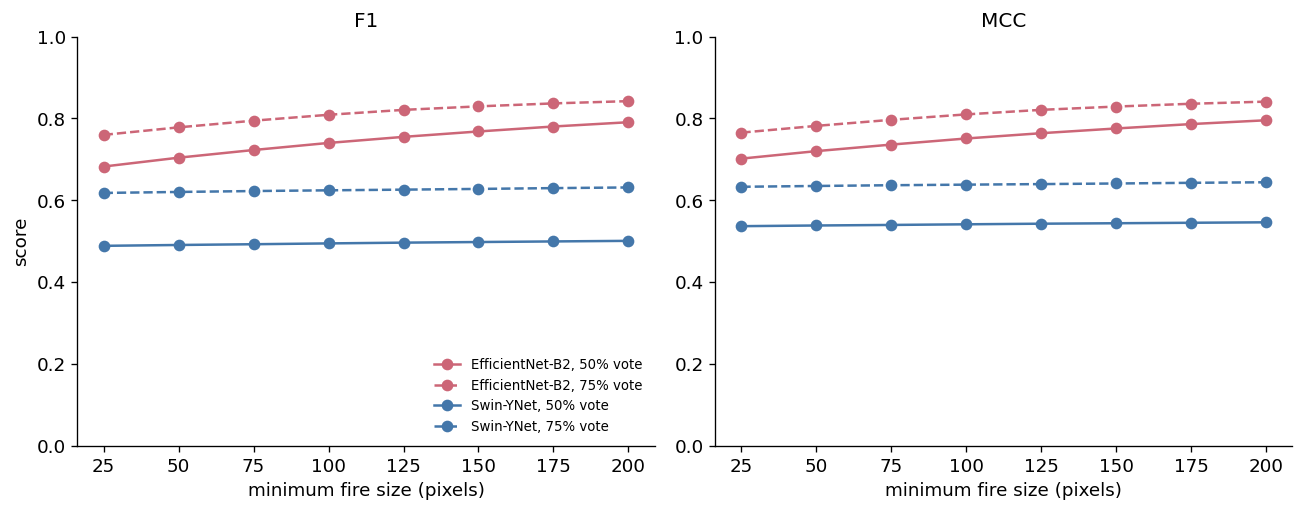

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True)
for ax, metric in zip(axes, ["F1", "MCC"]):
    for (mdl, vp), g in size_stats.groupby(["model", "vote_pct"]):
        ax.plot(g["min_size_px"], g[metric], "o", linestyle=VOTE_LS[vp],
                color=MODEL_COLOR[mdl], label=f"{MODEL_LABEL[mdl]}, {vp}% vote")
    ax.set_title(metric); ax.set_xlabel("minimum fire size (pixels)")
    ax.set_xticks(THRESHOLDS); ax.set_ylim(0, 1)
axes[0].set_ylabel("score"); axes[0].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

*Observation.* EfficientNet stays above Swin-YNet, and within each model the
75 percent vote (dashed) starts higher than the 50 percent vote (solid). Raising
the minimum size lifts every curve, so the size filter still helps even after the
vote has removed some false alarms.

#### 2.1.3 Precision and recall

**Objective.** Show the trade directly. **Assumption.** Same lines as above.

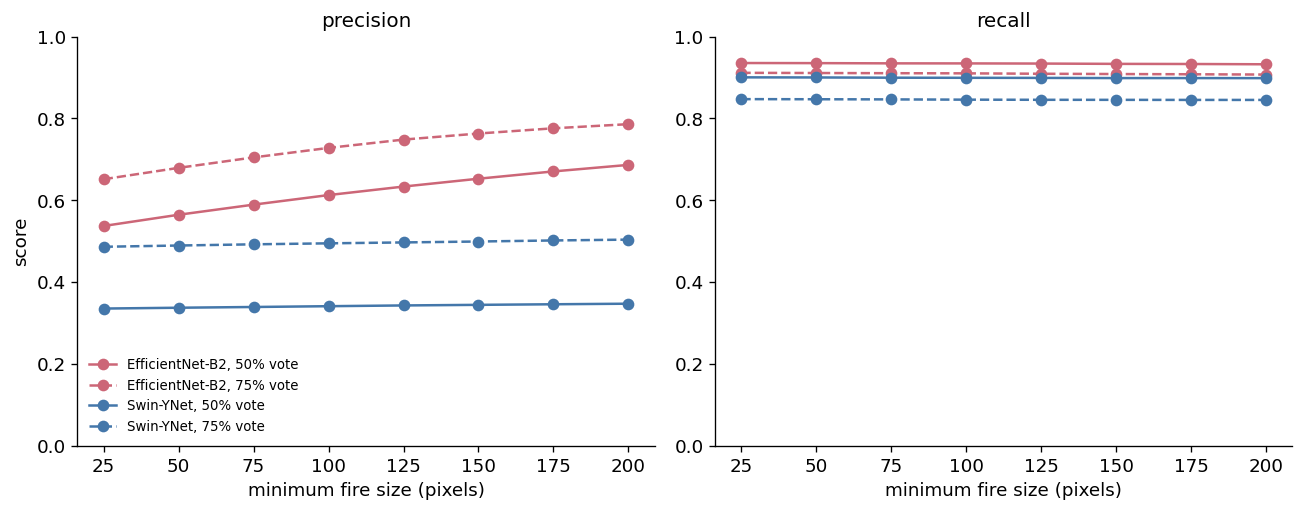

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True)
for ax, metric in zip(axes, ["precision", "recall"]):
    for (mdl, vp), g in size_stats.groupby(["model", "vote_pct"]):
        ax.plot(g["min_size_px"], g[metric], "o", linestyle=VOTE_LS[vp],
                color=MODEL_COLOR[mdl], label=f"{MODEL_LABEL[mdl]}, {vp}% vote")
    ax.set_title(metric); ax.set_xlabel("minimum fire size (pixels)")
    ax.set_xticks(THRESHOLDS); ax.set_ylim(0, 1)
axes[0].set_ylabel("score"); axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

*Observation.* Precision climbs as small patches are dropped, while recall
falls only gently, since real fires are large and survive the filter. The trade is
favourable for both vote settings.

#### 2.1.4 Burned area versus the threshold

**Objective.** Track the total flagged area against the actual fire. **Assumption.**
Burned area is the flagged area on the scored pixels.

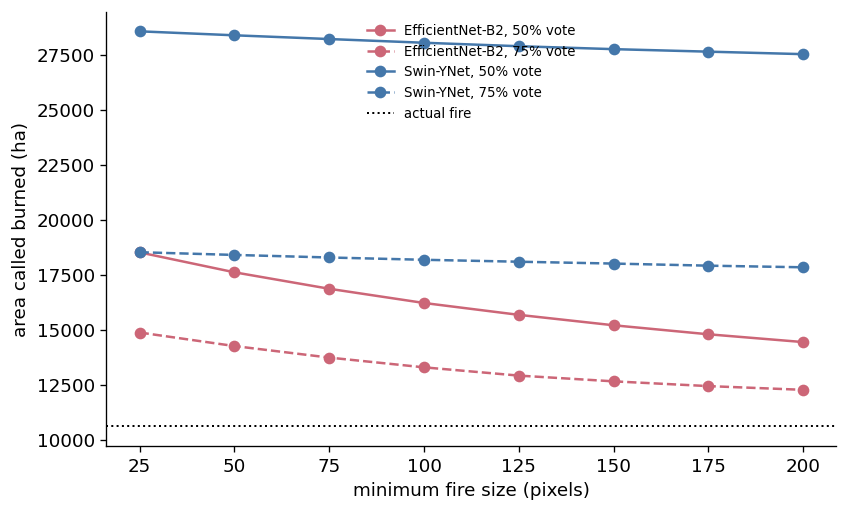

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for (mdl, vp), g in size_stats.groupby(["model", "vote_pct"]):
    ax.plot(g["min_size_px"], g["burned_ha"], "o", linestyle=VOTE_LS[vp],
            color=MODEL_COLOR[mdl], label=f"{MODEL_LABEL[mdl]}, {vp}% vote")
ax.axhline(t.sum()*PIX_HA, ls=":", color="black", lw=1.2, label="actual fire")
ax.set_xlabel("minimum fire size (pixels)"); ax.set_ylabel("area called burned (ha)")
ax.set_xticks(THRESHOLDS); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

*Observation.* The flagged area falls toward the actual fire line as the
filter tightens, and the 75 percent vote starts closer to it than the 50 percent
vote.

## 3. Spatial view

This section maps the effect on the ground at the strict (75 percent) vote, so the
reader can see which patches the size filter removes.

### 3.1 Where the filter cleans up

Agreement maps (violet = true positive, red = false positive, blue = false
negative) at three minimum sizes, for the 75 percent vote.

#### 3.1.1 Agreement maps at selected minimum sizes

**Objective.** Map true and false positives at minimum sizes of 25, 100 and 200
pixels, for both models, at 50% overlap and a 75 percent vote. **Assumption.** Maps
are shrunk for display, Portugal boundary drawn.

In [8]:
SHOW = [25, 100, 200]
MAP_VOTE = 75

def pool_or(a, k=12):
    H, W = (a.shape[0]//k)*k, (a.shape[1]//k)*k
    return a[:H, :W].reshape(H//k, k, W//k, k).max(axis=(1, 3))

def confusion_rgb(mdl, vp, ms):
    p = filtered_pred(mdl, vp, ms)
    TP, FP, FN = pool_or(p & t), pool_or(p & ~t), pool_or(~p & t)
    img = np.ones(TP.shape + (3,))
    for m, c in [(FN, C_MISS), (FP, C_FALSE), (TP, C_AGREE)]:
        img[m] = mcolors.to_rgb(c)
    return img

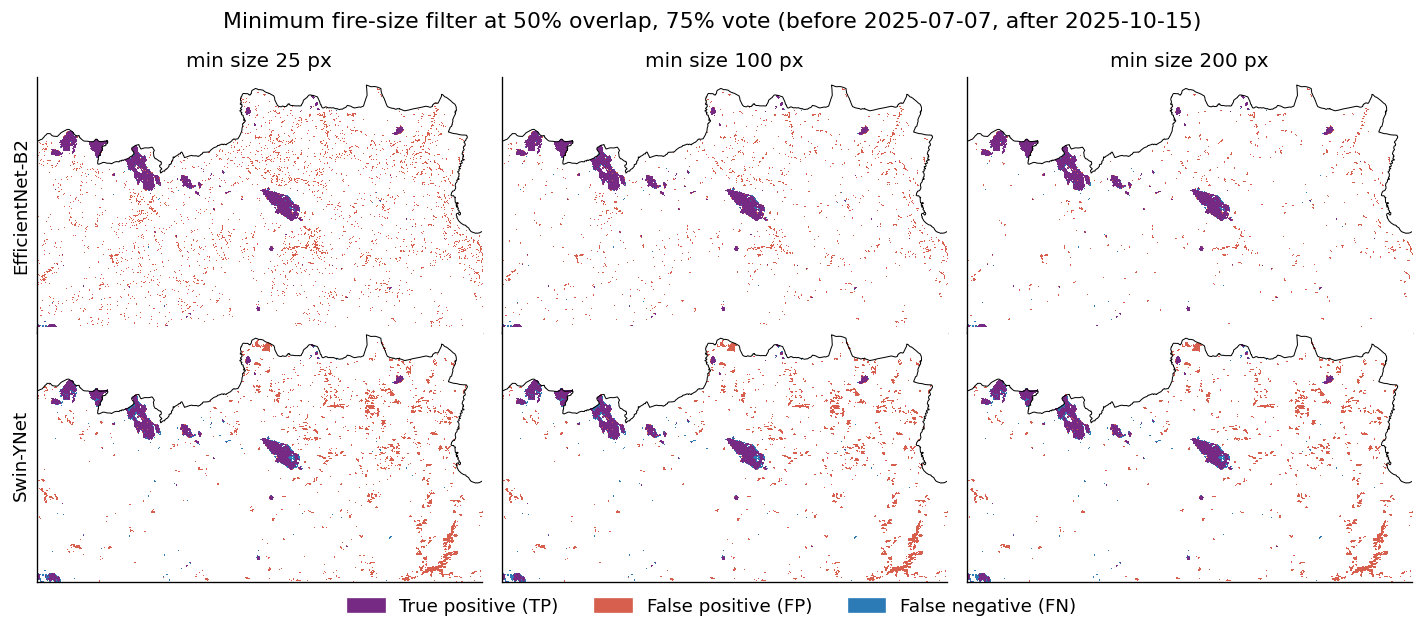

In [9]:
fig, axes = plt.subplots(len(MODELS), len(SHOW), figsize=(4*len(SHOW), 2.6*len(MODELS)))
axes = np.atleast_2d(axes)
for i, mdl in enumerate(MODELS):
    for j, ms in enumerate(SHOW):
        ax = axes[i, j]
        ax.imshow(confusion_rgb(mdl, MAP_VOTE, ms), extent=EXTENT, origin="upper", interpolation="nearest")
        PT.boundary.plot(ax=ax, color="black", linewidth=0.6)
        ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3])
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0: ax.set_title(f"min size {ms} px")
        if j == 0: ax.set_ylabel(MODEL_LABEL[mdl])
handles = [mpatches.Patch(color=C_AGREE, label="True positive (TP)"),
           mpatches.Patch(color=C_FALSE, label="False positive (FP)"),
           mpatches.Patch(color=C_MISS,  label="False negative (FN)")]
fig.suptitle(f"Minimum fire-size filter at 50% overlap, {MAP_VOTE}% vote "
             f"(before {BEFORE}, after {AFTER})", y=0.99)
fig.legend(handles=handles, loc="lower center", ncol=3)
plt.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

*Observation.* Left to right, the red false positives thin out while the
violet fires stay. For EfficientNet (top) the removed patches are scattered specks;
for Swin-YNet (bottom) some larger blobs remain that the size filter cannot reach.

## 4. Fire-count vs. burned-area trade-off at high thresholds

Adapted from `efficientnet_evaluation.ipynb` section 4 (4.1.1–4.1.3), then extended
to compare both models rather than EfficientNet-B2 alone. The sweep in section 2
caps the minimum-size filter at 200 px. Pushing it much higher (up to 1,000 px)
asks a different question: does the filter trade off the *number* of fires
detected against the *area* burned correctly, and does that trade-off differ
between the two models? Reuses `filtered_pred`, `confusion_rgb`, `t`, `comp`, `mcc`
and the patches already labelled in section 1.2 — only the size cutoff and
threshold range are new.

### 4.1 Wider size sweep, both models (50% overlap)

#### 4.1.1 Scores by vote and minimum size, 25–1000 px

**Objective.** Extend the minimum-size sweep from 200 px (section 2) to 1,000 px
for both models, to see where precision/F1/MCC plateau and whether the two models
plateau at the same point. **Assumption.** Same connected-component patches
labelled in section 1.2 — only the size cutoff applied to them changes, so no
relabelling is needed.

In [ ]:
THRESHOLDS_WIDE = list(range(25, 1001, 50))   # extends the 25-200 px sweep in section 2

rows = []
for mdl in MODELS:
    for vp in VOTE_PCTS:
        for ms in THRESHOLDS_WIDE:
            p = filtered_pred(mdl, vp, ms)
            TP = int((p & t).sum()); FP = int((p & ~t).sum())
            FN = int((~p & t).sum()); TN = int((~p & ~t & comp).sum())
            rows.append({"model": mdl, "vote_pct": vp, "min_size_px": ms,
                         "burned_ha": (TP+FP)*PIX_HA,
                         "precision": TP/(TP+FP), "recall": TP/(TP+FN),
                         "F1": 2*TP/(2*TP+FP+FN), "MCC": mcc(TP, FP, FN, TN)})
size_stats_wide = pd.DataFrame(rows)
size_stats_wide.round({"burned_ha": 0, "precision": 3, "recall": 3, "F1": 3, "MCC": 3})

In [ ]:
MET_COL = {"precision": "#4477aa", "recall": "#ee6677", "F1": "#228833", "MCC": "#aa3377"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, mdl in zip(axes, MODELS):
    g_mdl = size_stats_wide[size_stats_wide.model == mdl]
    for vp in VOTE_PCTS:
        g = g_mdl[g_mdl.vote_pct == vp].sort_values("min_size_px")
        for m in ["precision", "recall", "F1", "MCC"]:
            ax.plot(g["min_size_px"], g[m], marker="o", ms=3, linestyle=VOTE_LS[vp],
                     color=MET_COL[m],
                     label=f"{m}, {vp}% vote" if mdl == MODELS[0] else None)
    ax.set_title(MODEL_LABEL[mdl]); ax.set_xlabel("minimum fire size (pixels)")
    ax.set_xticks(range(0, 1001, 200)); ax.set_ylim(0.2, 1)
axes[0].set_ylabel("score"); axes[0].legend(fontsize=7, loc="lower right", ncol=2)
fig.suptitle("Metrics versus minimum fire size, 25-1000 px (50% overlap)", y=1.02)
plt.tight_layout(); plt.show()

*Observation.* Extending the sweep to 1,000 px shows the section 2 trend keeps climbing, but not equally for both models. At the 75 percent vote, EfficientNet-B2's MCC rises from 0.765 at 25 px (matching the headline number in the README) to 0.893 at 975 px, while recall barely moves (0.911 → 0.898); Swin-YNet's MCC over the same range only goes from 0.633 to 0.676, with a similarly small recall change (0.847 → 0.839). The 50 percent vote shows the same pattern at a lower level: EfficientNet-B2 MCC 0.702 → 0.878, Swin-YNet 0.537 → 0.573. Since the recall cost is small and almost identical for both models, the gain is essentially a precision effect, and EfficientNet-B2 captures most of it; Swin-YNet's curves flatten out far short of EfficientNet-B2's, so the gap between the two models does not close as the filter widens — in absolute MCC terms it widens.

#### 4.1.2 Where the size filter cleans up

**Objective.** Map agreement and error at minimum sizes 25, 250, 500, 750 and
1,000 px, at the 75 percent vote, for both models side by side.
**Assumption.** Maps shrunk for display, same as section 3.

In [ ]:
SHOW_WIDE = [25, 250, 500, 750, 1000]
fig, axes = plt.subplots(len(MODELS), len(SHOW_WIDE), figsize=(4*len(SHOW_WIDE), 2.6*len(MODELS)))
axes = np.atleast_2d(axes)
for i, mdl in enumerate(MODELS):
    for j, ms in enumerate(SHOW_WIDE):
        ax = axes[i, j]
        ax.imshow(confusion_rgb(mdl, MAP_VOTE, ms), extent=EXTENT, origin="upper", interpolation="nearest")
        PT.boundary.plot(ax=ax, color="black", linewidth=0.6)
        ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3])
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0: ax.set_title(f"min size {ms} px")
        if j == 0: ax.set_ylabel(MODEL_LABEL[mdl])
handles = [mpatches.Patch(color=C_AGREE, label="True positive (TP)"),
           mpatches.Patch(color=C_FALSE, label="False positive (FP)"),
           mpatches.Patch(color=C_MISS,  label="False negative (FN)")]
fig.suptitle(f"Minimum fire size at 50% overlap, {MAP_VOTE}% vote "
             f"(before {BEFORE}, after {AFTER})", y=0.99)
fig.legend(handles=handles, loc="lower center", ncol=3)
plt.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

In [ ]:
summary_rows = []
for mdl in MODELS:
    for ms in SHOW_WIDE:
        pred = filtered_pred(mdl, MAP_VOTE, ms)
        TP = int((pred & t).sum()); FP = int((pred & ~t).sum()); FN = int((~pred & t).sum())
        summary_rows.append({"model": mdl, "min_size_px": ms, "TP": TP, "FP": FP, "FN": FN,
                              "precision": TP/(TP+FP), "recall": TP/(TP+FN),
                              "F1": 2*TP/(2*TP+FP+FN)})
summary_table = pd.DataFrame(summary_rows).round({"precision": 3, "recall": 3, "F1": 3})
summary_table

*Observation.* The TP/FP breakdown in the table above explains the asymmetry seen in 4.1.1. From 25 px to 1,000 px, EfficientNet-B2 loses 1.6 percent of its true positives (969,438 → 954,869 px) but 77.8 percent of its false positives (518,870 → 115,198 px). Swin-YNet loses a comparable share of true positives (901,061 → 891,299 px, -1.1 percent) but only 25.7 percent of its false positives (952,172 → 707,101 px). EfficientNet-B2's false-positive area is concentrated in small, isolated patches that the size filter removes almost completely; a much larger share of Swin-YNet's false-positive area sits in patches large enough to survive even the 1,000 px cutoff — consistent with `false_positive_review.ipynb`'s finding that Swin-YNet's false alarms are more often real-looking ground features (e.g. river beds) rather than scattered noise.

#### 4.1.3 Pixel threshold vs. fire-count and burned-area accuracy

*Objective.* Whether raising the minimum-size threshold costs more in missed fire
*count* than in missed burned *area* — i.e. is the filter mostly cutting small
genuine fires, or noise — and whether that trade-off is the same for both models.

Fixed from the source notebook on copy: the original 4.1.3 plotted against an
undefined `miss_table` and used `gt_sizes` before it was computed two cells later
(an unresolved cell-ordering bug — it would `NameError` if run top to bottom even
in the source notebook). Reordered below so the ground-truth size distribution and
`comparison_table` are computed before anything plots them.

In [ ]:
# Ground-truth fire-size distribution within this window. Model-independent --
# depends only on `t`, the shared ground truth raster -- so this applies equally
# to both models' comparisons below.
gt_lab, n_gt = ndlabel(t)
gt_sizes = np.bincount(gt_lab.ravel())[1:]            # drop background label 0

print(f"distinct ground-truth fire patches in window: {n_gt}")
print(f"minimum true-fire size: {gt_sizes.min()} px  ({gt_sizes.min()*PIX_HA:.3f} ha)")
print(f"median: {np.median(gt_sizes):.0f} px, max: {gt_sizes.max()} px")

pd.Series(gt_sizes).sort_values().reset_index(drop=True)

In [ ]:
total_area = gt_sizes.sum()

rows = []
for mdl in MODELS:
    for ms in SHOW_WIDE:
        pred = filtered_pred(mdl, MAP_VOTE, ms)
        TP = int((pred & t).sum()); FP = int((pred & ~t).sum()); FN = int((~pred & t).sum())

        # n_missed / area_missed depend only on gt_sizes and ms, not on the model's
        # predictions -- they are identical across models at a given threshold.
        # TP/FP/FN are the model-specific part of this table.
        n_missed = int((gt_sizes < ms).sum())
        area_missed = int(gt_sizes[gt_sizes < ms].sum())

        rows.append({
            "model": mdl, "min_size_px": ms,
            "TP": TP, "FP": FP, "FN": FN,
            "n_fires_missed": n_missed, "n_fires_total": len(gt_sizes),
            "pct_fires_missed": n_missed / len(gt_sizes) * 100,
            "ha_missed": area_missed * PIX_HA,
            "pct_area_missed": area_missed / total_area * 100,
        })

comparison_table = pd.DataFrame(rows).round(
    {"pct_fires_missed": 1, "ha_missed": 1, "pct_area_missed": 2}
)
comparison_table

*Observation.* The 383 distinct ground-truth fire patches in this window range from 1 px to 319,798 px (about 0.01 to 3,198 ha), with a median of only 9 px (0.09 ha) — a heavily right-skewed distribution: most mapped fires are tiny, and a few are very large. That skew is exactly why the fire-count and burned-area costs of the filter diverge so sharply: at 1,000 px, 92.7 percent of fires are below the threshold by count (up from 59.0 percent at 25 px), yet only 2.34 percent of the total burned area is missed (up from 0.09 percent at 25 px), because the excluded fires are individually negligible. The two model rows in the table above are identical at every threshold, confirming this is a property of the ground truth, not of either model's predictions.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# left: TP / FP / FN per model, from the summary table built in 4.1.2
ax = axes[0]
for mdl in MODELS:
    g = summary_table[summary_table.model == mdl]
    ax.plot(g["min_size_px"], g["TP"], marker="o", linestyle="-",  color=MODEL_COLOR[mdl], label=f"{MODEL_LABEL[mdl]} TP")
    ax.plot(g["min_size_px"], g["FP"], marker="o", linestyle="--", color=MODEL_COLOR[mdl], label=f"{MODEL_LABEL[mdl]} FP")
    ax.plot(g["min_size_px"], g["FN"], marker="o", linestyle=":",  color=MODEL_COLOR[mdl], label=f"{MODEL_LABEL[mdl]} FN")
ax.set_xlabel("Minimum fire size (px)"); ax.set_ylabel("Pixel count")
ax.set_title(f"TP/FP/FN vs. minimum fire size ({MAP_VOTE}% vote)")
ax.legend(fontsize=7, ncol=2)

# right: percent of ground-truth fires missed -- shared across models, see note above
ax = axes[1]
g = comparison_table[comparison_table.model == MODELS[0]]
ax.plot(g["min_size_px"], g["pct_fires_missed"], marker="o", color=C_MISS)
ax.set_xlabel("Minimum fire size (px)"); ax.set_ylabel("Percent fires missed (%)")
ax.set_ylim(0, 100)
ax.set_title("Percent of ground-truth fires missed by min-size filter\n(model-independent)")

plt.tight_layout(); plt.show()

In [ ]:
fig, ax1 = plt.subplots(figsize=(7, 4.5))
bins = np.logspace(np.log10(gt_sizes.min()), np.log10(gt_sizes.max()), 25)

ax1.hist(gt_sizes, bins=bins, color=C_AGREE, edgecolor="white", alpha=0.85)
ax1.set_xscale("log")
ax1.set_xlabel("True fire size (px, log scale)")
ax1.set_ylabel("Count", color=C_AGREE)
ax1.tick_params(axis="y", colors=C_AGREE)
ax1.set_title(f"True fire size distribution by count vs. area (n={len(gt_sizes)})")

for ms in SHOW_WIDE:
    ax1.axvline(ms, color=C_FALSE, linestyle="--", linewidth=0.8)
    ax1.text(ms, ax1.get_ylim()[1]*0.95, f"{ms}px", color=C_FALSE, ha="center",
              fontsize=8, rotation=90, va="top")

bin_centers = np.sqrt(bins[:-1] * bins[1:])
area_ha, _ = np.histogram(gt_sizes, bins=bins, weights=gt_sizes * PIX_HA)

ax2 = ax1.twinx()
ax2.plot(bin_centers, area_ha, color=C_MISS, marker="o", markersize=3, linewidth=1.5)
ax2.set_ylabel("Area burned per bin (ha)", color=C_MISS)
ax2.tick_params(axis="y", colors=C_MISS)

plt.tight_layout(); plt.show()

*Observation.* Taken together, 4.1.1–4.1.3 show the wide size filter is close to free in area terms for both models — recall loss under 2 points, burned area missed under 2.4 percent even at 1,000 px — but the precision/MCC payoff is not shared equally: EfficientNet-B2 turns it into a large gain because its false positives sit in small patches; Swin-YNet's false positives are larger and mostly survive. Reporting the fire-count-missed figure alone (up to 92.7 percent) would make the filter look far more costly than it is; reporting it alongside the area-missed figure (under 2.4 percent) gives the fair picture, and that picture does not depend on which model's predictions are being filtered.

## 5. Summary

On the 25–200 px range (section 2), raising the minimum fire size still helps after the vote has already filtered some false alarms: F1 and MCC rise for every model and vote threshold, precision climbs, and recall falls only gently because real fires are far larger than the threshold. The strict 75 percent vote starts ahead of the plain 50 percent vote and stays ahead. EfficientNet-B2 leads Swin-YNet throughout, mainly because Swin-YNet's remaining false alarms include larger blobs the filter at this range cannot reach.

Extending the sweep to 1,000 px (section 4) confirms that pattern rather than changing it. At the 75 percent vote, MCC keeps climbing for EfficientNet-B2 (0.765 at 25 px to 0.893 at 975 px) while recall barely moves (0.911 to 0.898); the same filter takes Swin-YNet from 0.633 to only 0.676, with an equally small recall cost. The TP/FP breakdown shows why: EfficientNet-B2 sheds 77.8 percent of its false-positive area over that range against a 1.6 percent true-positive loss, while Swin-YNet sheds only 25.7 percent of its false-positive area for a comparable 1.1 percent true-positive loss. EfficientNet-B2's false positives are concentrated in small, easily-filtered patches; a large share of Swin-YNet's are not, which fits the false-positive review's finding that Swin-YNet's false alarms are often real-looking features such as river channels rather than scattered noise. The size filter does not close the gap between the two models — at the widest threshold tested it is, in absolute MCC terms, no smaller than at 25 px.

The ground-truth fire-size distribution itself (383 fires in this window, 1 to 319,798 px, median 9 px) is the reason the filter's two costs look so different depending on how you measure them: by fire count, 1,000 px already excludes 92.7 percent of mapped fires; by burned area, the same threshold misses only 2.34 percent, because the excluded fires are individually tiny and the area is concentrated in a handful of large ones. This split is identical for both models, since it depends only on the ground truth. A minimum-size filter in the hundreds of pixels is close to free in area-of-burn terms for both models, but reporting only the fire-count-missed figure would make it look far more destructive than it is.

Net read: a wide minimum-size filter (anywhere from ~500 to 1,000 px) is worth applying for EfficientNet-B2, where it converts almost entirely into a precision/MCC gain at negligible recall cost; for Swin-YNet the same filter is harmless but far less rewarding, because its false-positive area is not concentrated in the small patches the filter targets. Confirm EfficientNet-B2's class/band order with the model author before treating its absolute numbers as final — this would not change the *relative* pattern reported here, which holds across the full 25–1,000 px range and both vote thresholds, but it bears on how much weight to put on the absolute precision/MCC values themselves.